In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import os

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
print(esc_fresnel.path)

from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.utils as utils
import esc_fresnel.dm as dm
import esc_fresnel.esc_fresnel_subap as esc
import esc_fresnel.esc_optics as esc_optics


/home/kianmilani/Projects/esc-fresnel/esc_fresnel


In [86]:
4096**2 * 25 * 2 * 8 / 1e9

6.7108864

# Create an instance of the Fresnel model and check some of the parameters used in the propagation code. 

True
True
True


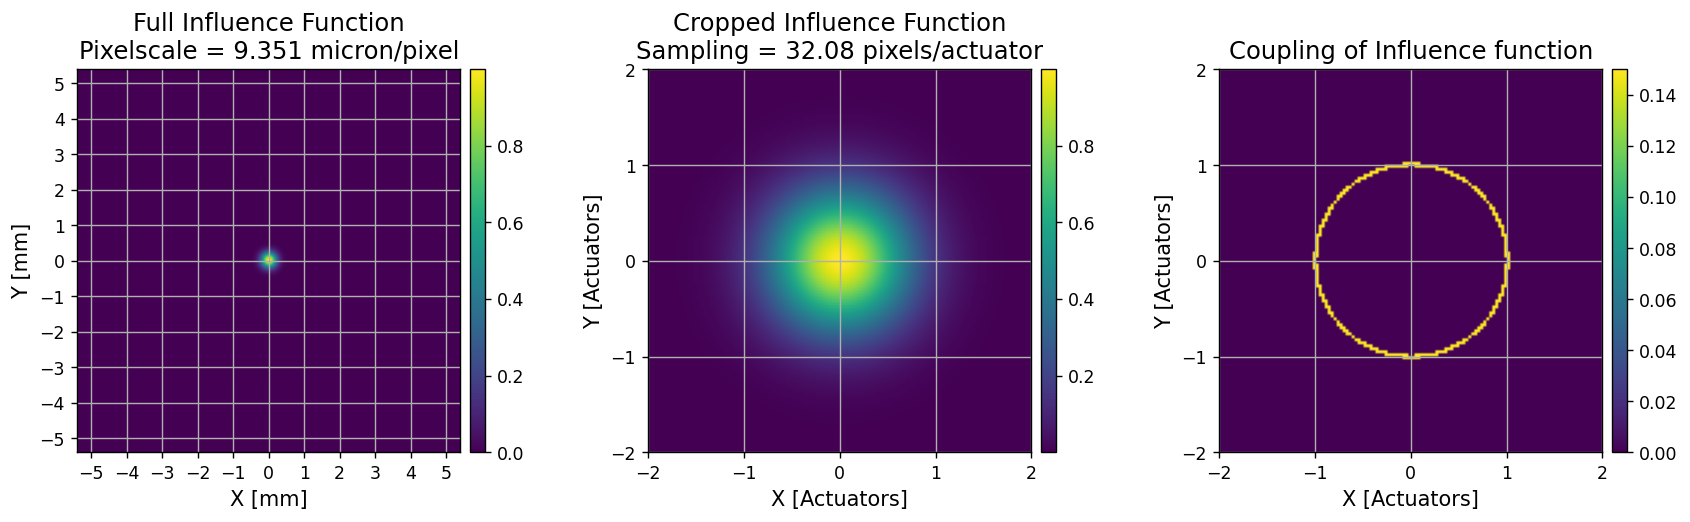

True
True


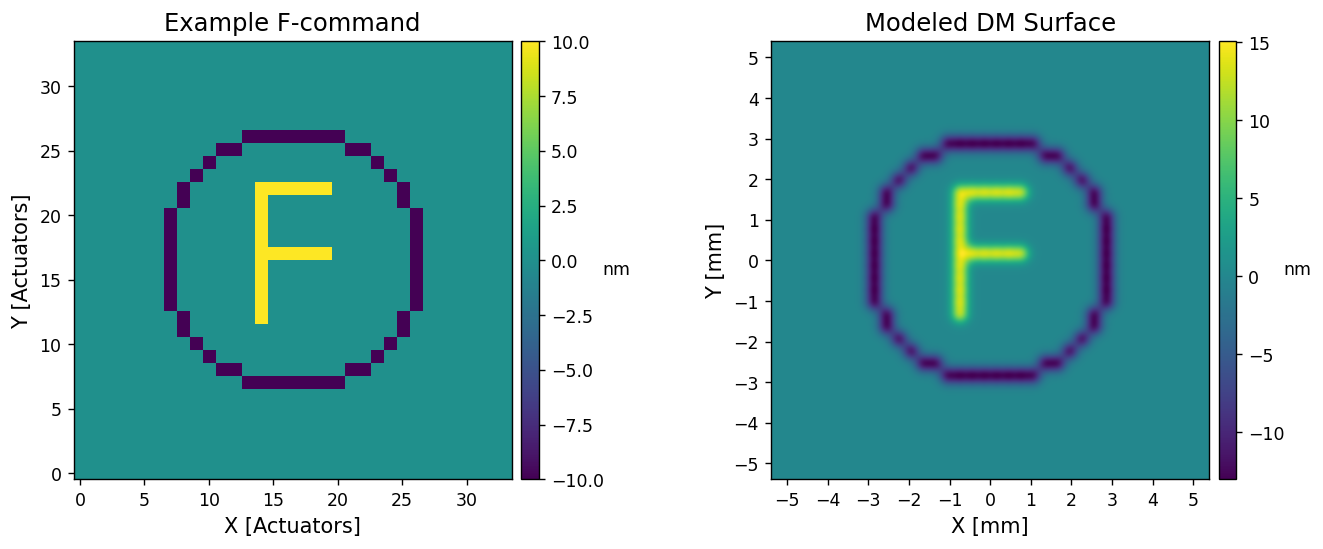

In [4]:
reload(esc)
reload(utils)
M = esc.single()

inf_fun_coupling_region = (0.15-0.01<M.DM.inf_fun) & (M.DM.inf_fun<0.15+0.01)

full_ticks = np.arange(-5, 5.01, 1)
crop_ticks = np.arange(-2, 2.01, 1)
utils.imshow(
    [M.DM.inf_fun, M.DM.inf_fun, inf_fun_coupling_region],
    titles=[f'Full Influence Function\nPixelscale = {M.DM.pixelscale.to_value(u.um/u.pix):.3f} micron/pixel', 
            f'Cropped Influence Function\nSampling = {M.DM.inf_sampling:.2f} pixels/actuator', 
            'Coupling of Influence function'],
    xlabels=['X [mm]', 'X [Actuators]', 'X [Actuators]'],
    ylabels=['Y [mm]', 'Y [Actuators]', 'Y [Actuators]'],
    title_fzs=[14]*3,
    label_fzs=[12]*3,
    pxscls=[M.DM.pixelscale.to_value(u.mm/u.pix), 1/M.DM.inf_sampling, 1/M.DM.inf_sampling],
    xticks=[full_ticks, crop_ticks, crop_ticks],
    yticks=[full_ticks, crop_ticks, crop_ticks],
    cmaps=['viridis']*3,
    grids=[1, 1, 1],
    norms=[None, None, Normalize(vmax=0.15)],
    npix=[None, int(np.round(4*M.DM.inf_sampling)), int(np.round(4*M.DM.inf_sampling))],
    wspace=0.4,
    figsize=(16,5),
)

f = 10* (-utils.make_ring(rad=10) + utils.make_f(h=10, w=6, shift=(-1,0)))
M.set_dm(f)
surf = M.DM.get_surface()

utils.imshow(
    [f, surf],
    titles=[f'Example F-command', 
            f'Modeled DM Surface',],
    xlabels=['X [Actuators]', 'X [mm]',],
    ylabels=['Y [Actuators]', 'Y [mm]'],
    title_fzs=[14]*3,
    label_fzs=[12]*3,
    pxscls=[None, M.DM.pixelscale.to_value(u.mm/u.pix),],
    xticks=[None, full_ticks],
    yticks=[None, full_ticks],
    cmaps=['viridis']*3,
    cbar_labels=['nm', 'nm'],
    grids=[False, False],
    norms=[None, None],
    npix=[None, None],
    wspace=0.5,
    figsize=(12,5),
)


# Do a propagation without any surface errors.

In [5]:
import esc_fresnel.esc_fresnel_subap as esc

reload(esc)
reload(esc_optics)

# poppy_log.disabled = False
poppy_log.disabled = True

M = esc.single()

ref_psf = M.snap()

M.Imax_ref = xp.max(ref_psf)
M.use_vortex = True
# ref_coro_im = M.snap()
wfs = M.calc_wfs()
ref_coro_im = wfs[-1].intensity / M.Imax_ref

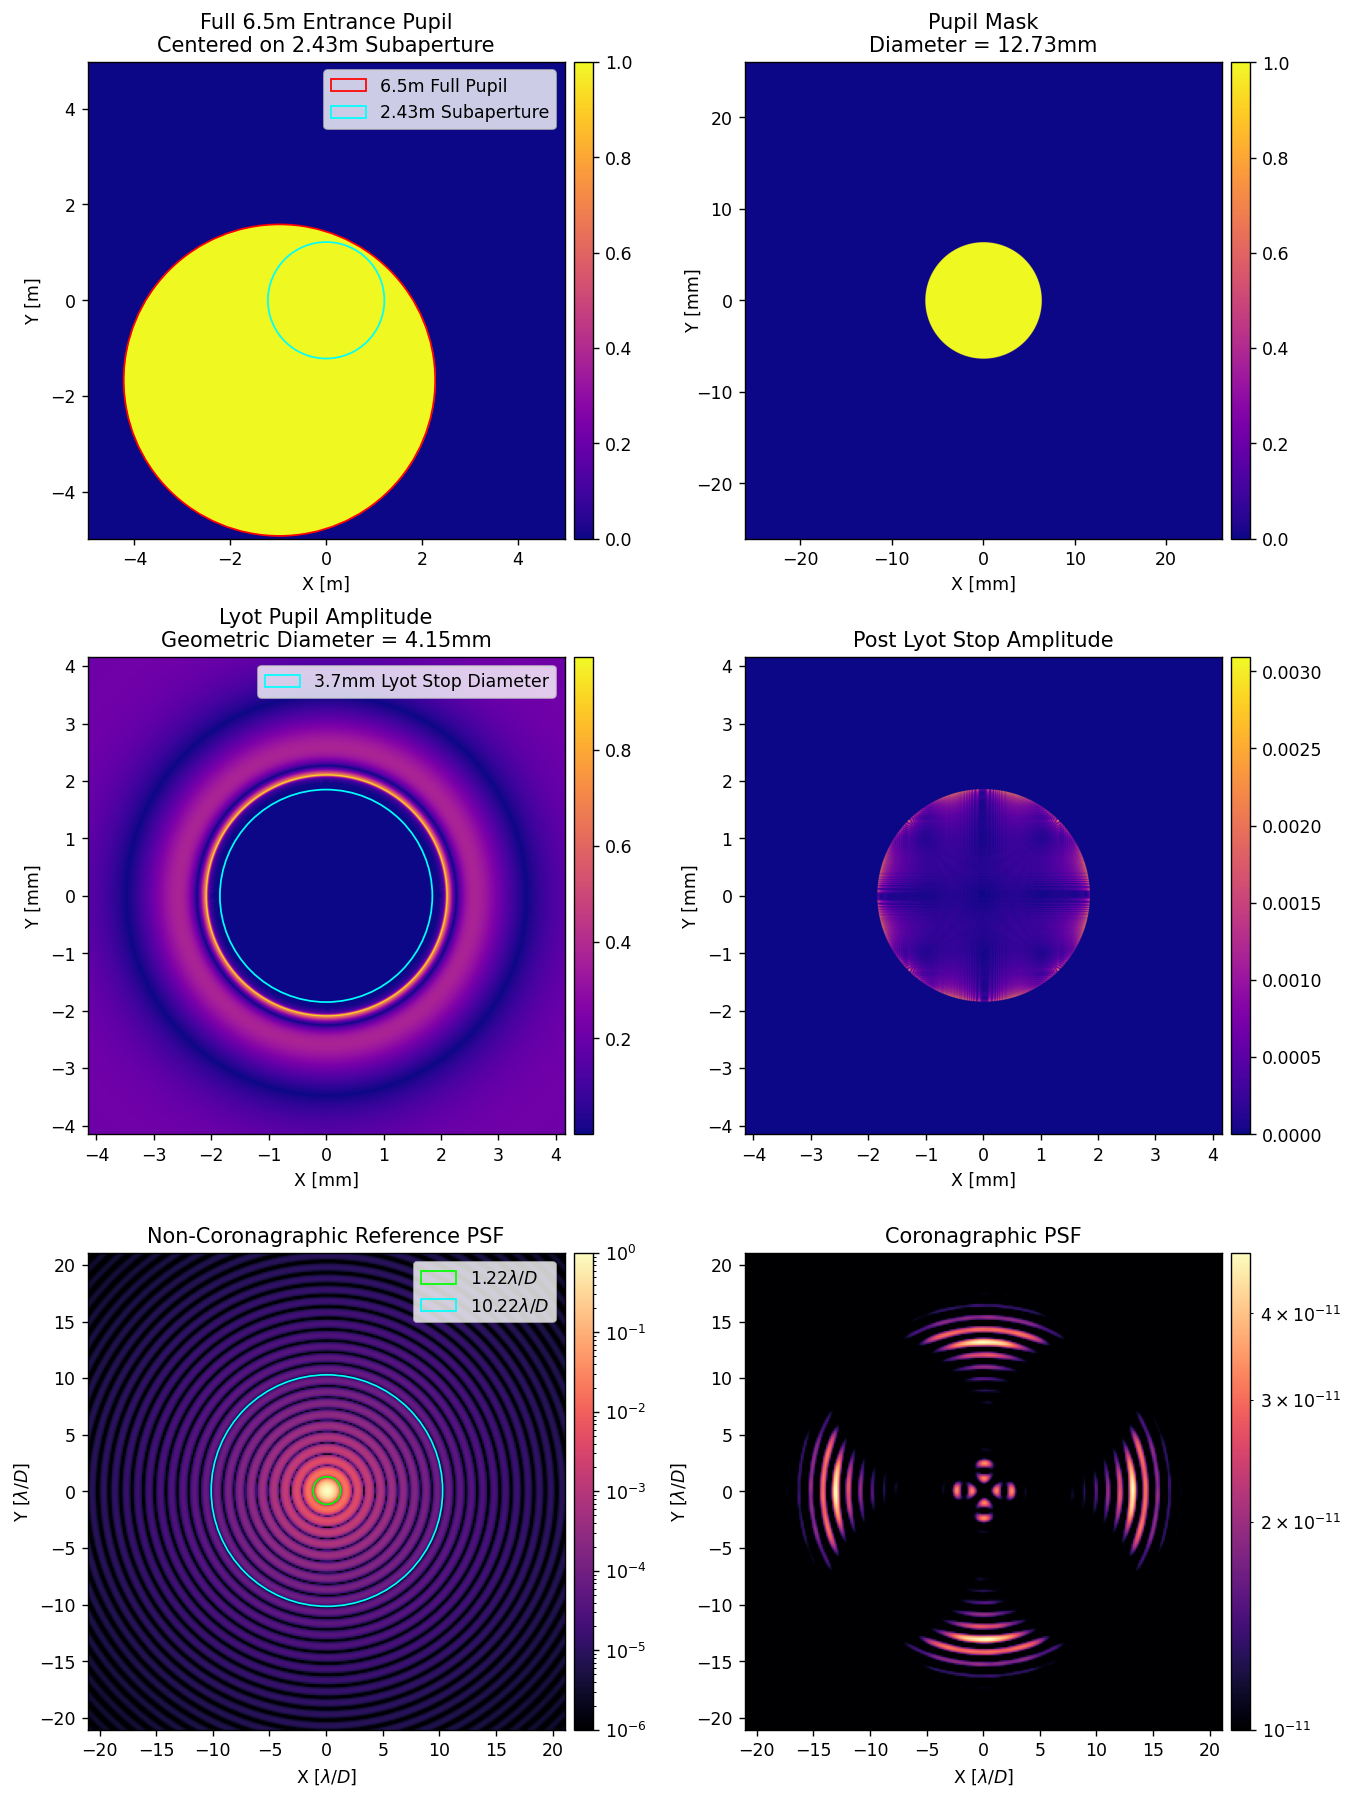

In [10]:
reload(utils)
ipup = 0
ipup_mask = 9
ilp = 25
ils = 26

pup_center = (M.FULL_EP.shift_x.to_value(u.m), M.FULL_EP.shift_y.to_value(u.m))
psf_center = (M.camsci_pxscl_lamDc/2, M.camsci_pxscl_lamDc/2)
fig, axs = utils.imshow(
    [wfs[ipup].amplitude, wfs[ipup_mask].amplitude, 
     wfs[ilp].amplitude, wfs[ils].amplitude,
     ref_psf/M.Imax_ref, ref_coro_im], 
    titles=[
        f'Full 6.5m Entrance Pupil\nCentered on 2.43m Subaperture',
        f'Pupil Mask\nDiameter = {M.pupil_mask_diam.to_value(u.mm):.2f}mm',
        f'Lyot Pupil Amplitude\nGeometric Diameter = {2*wfs[ilp].spot_radius().to_value(u.mm):.2f}mm', 
        f'Post Lyot Stop Amplitude', 
        'Non-Coronagraphic Reference PSF',
        'Coronagraphic PSF',
    ],
    cmaps=['plasma']*4 + ['magma', 'magma'],
    norms=[None, ]*4 + [LogNorm(1e-6), LogNorm(1e-11)],
    npix=[None, None, 2000, 2000],
    pxscls=[
        wfs[ipup].pixelscale.to_value(u.m/u.pix),
        wfs[ipup_mask].pixelscale.to_value(u.mm/u.pix),
        wfs[ilp].pixelscale.to_value(u.mm/u.pix),
        wfs[ils].pixelscale.to_value(u.mm/u.pix),
        M.camsci_pxscl_lamDc,
        M.camsci_pxscl_lamDc,
    ],
    xlabels=['X [m]', 'X [mm]', 'X [mm]', 'X [mm]', 'X [$\lambda/D$]', 'X [$\lambda/D$]'],
    ylabels=['Y [m]', 'Y [mm]', 'Y [mm]', 'Y [mm]', 'Y [$\lambda/D$]', 'Y [$\lambda/D$]'],
    title_fzs=[12]*6,
    label_fzs=[10]*6,
    ylabel_pads=[None, -4, None, None],
    all_patches=[ 
        [Circle(pup_center, 6.5/2, fill=False, color='red', label='6.5m Full Pupil'), 
         Circle((0,0), 2.43/2, fill=False, color='cyan', label='2.43m Subaperture')],
        None, 
        [Circle((0,0), M.lyot_stop_diam.to_value(u.mm)/2, fill=False, color='cyan', label='3.7mm Lyot Stop Diameter')],
        None, 
        [Circle(psf_center, 1.22, fill=False, color='lime', label='1.22$\lambda/D$'), 
         Circle(psf_center, 10.22, fill=False, color='cyan', label='10.22$\lambda/D$')],
        None,
    ],
    # figsize=(16,5),
    Nrows=3, Ncols=2, figsize=(12, 18),
    wspace=0.3, hspace=0.1,
    return_fig=1,
)
axs[0,0].legend()
axs[1,0].legend()
axs[2,0].legend()
display(fig)

# psf_center = (M.camsci_pxscl_lamDc/2, M.camsci_pxscl_lamDc/2)
# fig, axs = utils.imshow(
#     [ref_psf/M.Imax_ref, ref_coro_im], 
#     titles=[
#         f'Full 6.5m Entrance Pupil\nCentered on 2.43m Subaperture',
#         f'Pupil Mask Selecting\nDiameter = {M.pupil_mask_diam.to_value(u.mm):.1f}mm',
#     ],
#     cmaps=['magma', 'magma'],
#     norms=[LogNorm(1e-6), LogNorm(1e-11)],
#     pxscls=[M.camsci_pxscl_lamDc]*2,
#     all_patches=[ 
#         [Circle(psf_center, 1.22, fill=False, color='lime', label='1.22$\lambda/D$'), 
#          Circle(psf_center, 10.22, fill=False, color='cyan', label='10.22$\lambda/D$')] 
#     ],
#     return_fig=1,
# )
# axs[0].legend()
# display(fig)


In [91]:
wfe_dir = 'V20250325-cropped'
wfe_dir = 'V20250326-cropped'

dm_flat = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_flat.fits')
prefpm_opd = xp.rot90(xp.rot90(utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/f'prefpm_opd.fits') ))

wfe_keys = [
    'm1',
    'm2',
    'm3', 
    'm4',
    'oap1',
    'fm1',
    'oap2',
    'oap3',
    'fsm',
    'fm2',
    'oap4',
    'oap5',
    'input_lp',
    'input_qwp',
    'oap6',
    'oap7',
    'oap9',
    'collimator',
    'filter',
    'output_qwp',
    'output_lp',
    'oap10',
]

wfes = {}
for optic in wfe_keys:
    wfe = poppy.FITSOpticalElement(
        opd=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_opd.fits'), 
        opdunits='nanometers',
        transmission=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_amp.fits'),
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

# dm_map = poppy.FITSOpticalElement(
#     opd=str(esc_fresnel.path/'wfe-maps'/'bmc952dm_flat.fits'), 
#     opdunits='meters',
#     name=f'dm_wfe',
#     pixelscale='SCALE',
#     planetype=poppy.poppy_core.PlaneType.intermediate,
# )
# dm_map.opd *= 2

dm_map = poppy.FITSOpticalElement(
    opd=str(esc_fresnel.path/'wfe-maps'/'bmc952dm_flat_interpped.fits'), 
    opdunits='meters',
    name=f'dm_wfe',
    planetype=poppy.poppy_core.PlaneType.intermediate,
)

wfes.update({'DM':dm_map})


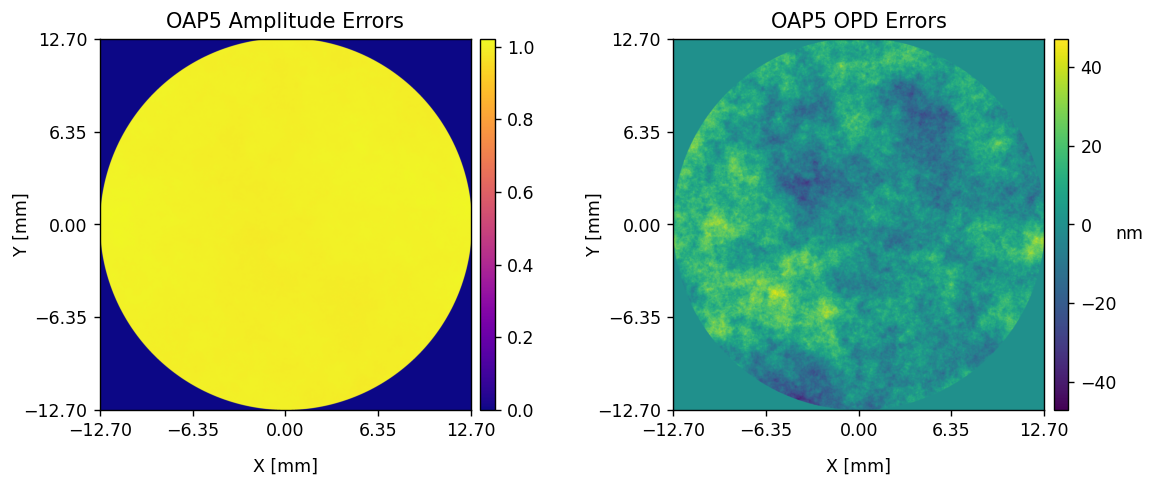

In [54]:
optic = 'oap5'
wfe_dir = 'V20250326'

wfe = poppy.FITSOpticalElement(
    opd=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_full_opd.fits'), 
    opdunits='nanometers',
    transmission=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_full_amp.fits'),
    name=f'{optic}_wfe',
    planetype=poppy.poppy_core.PlaneType.intermediate,
)
wfes[optic] = wfe

N = wfe.shape[0]
xmax = wfe.pixelscale.to_value(u.mm/u.pix) * N/2
ticks = np.linspace(-xmax, xmax, 5)
utils.imshow(
    [wfe.amplitude, wfe.opd*1e9],
    titles=[f'{optic.upper()} Amplitude Errors', f'{optic.upper()} OPD Errors', ],
    title_fzs=[12]*2,
    cmaps=['plasma', 'viridis'],
    pxscls=[wfe.pixelscale.to_value(u.mm/u.pix)]*2,
    xlabels=['X [mm]']*2,
    ylabels=['Y [mm]']*2,
    ylabel_pads=[-4]*2,
    xlabel_pads=[10]*2,
    xticks=[ticks, ticks],
    yticks=[ticks, ticks],
    cbar_labels=[None, 'nm'],
    norms=[None, CenteredNorm()],
    # norms=[CenteredNorm(vcenter=1, halfrange=0.05), CenteredNorm()],
    wspace=0.45,
    # npix=[100]*2,
)

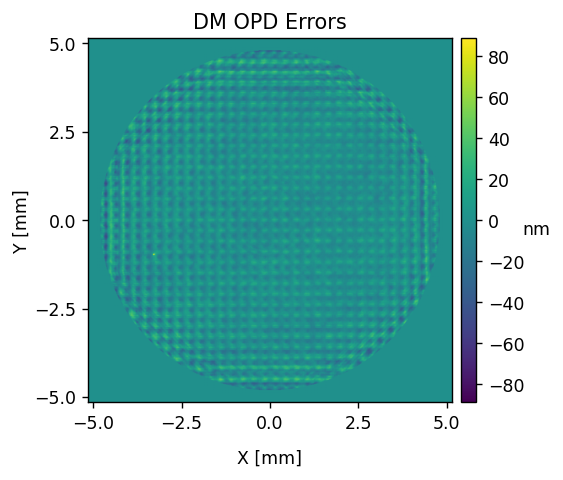

In [66]:
dm_map = poppy.FITSOpticalElement(
    opd=str(esc_fresnel.path/'wfe-maps'/'bmc952dm_flat_interpped.fits'), 
    opdunits='meters',
    name=f'dm_wfe',
    planetype=poppy.poppy_core.PlaneType.intermediate,
)

N = 1100
xmax = -5
ticks = np.linspace(-xmax, xmax, 5)
utils.imshow(
    [dm_map.opd*1e9],
    npix=[N, N],
    titles=[f'DM OPD Errors', ],
    title_fzs=[12]*2,
    cmaps=['viridis'],
    pxscls=[dm_map.pixelscale.to_value(u.mm/u.pix)]*2,
    xlabels=['X [mm]']*2,
    ylabels=['Y [mm]']*2,
    ylabel_pads=[2]*2,
    xlabel_pads=[10]*2,
    xticks=[ticks, ticks],
    yticks=[ticks, ticks],
    cbar_labels=['nm'],
    norms=[CenteredNorm()],
    # norms=[CenteredNorm(vcenter=1, halfrange=0.05), CenteredNorm()],
    wspace=0.45,
    # npix=[100]*2,
)

# Compute the focal plane image with and without the vortex.

In [99]:
34 * 9.351 / 10.2 * 3.7/4.153

27.770045750060206

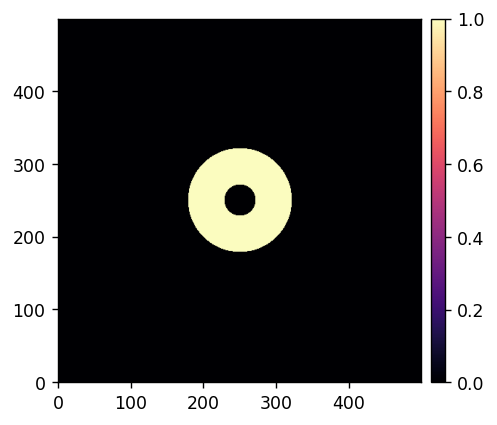

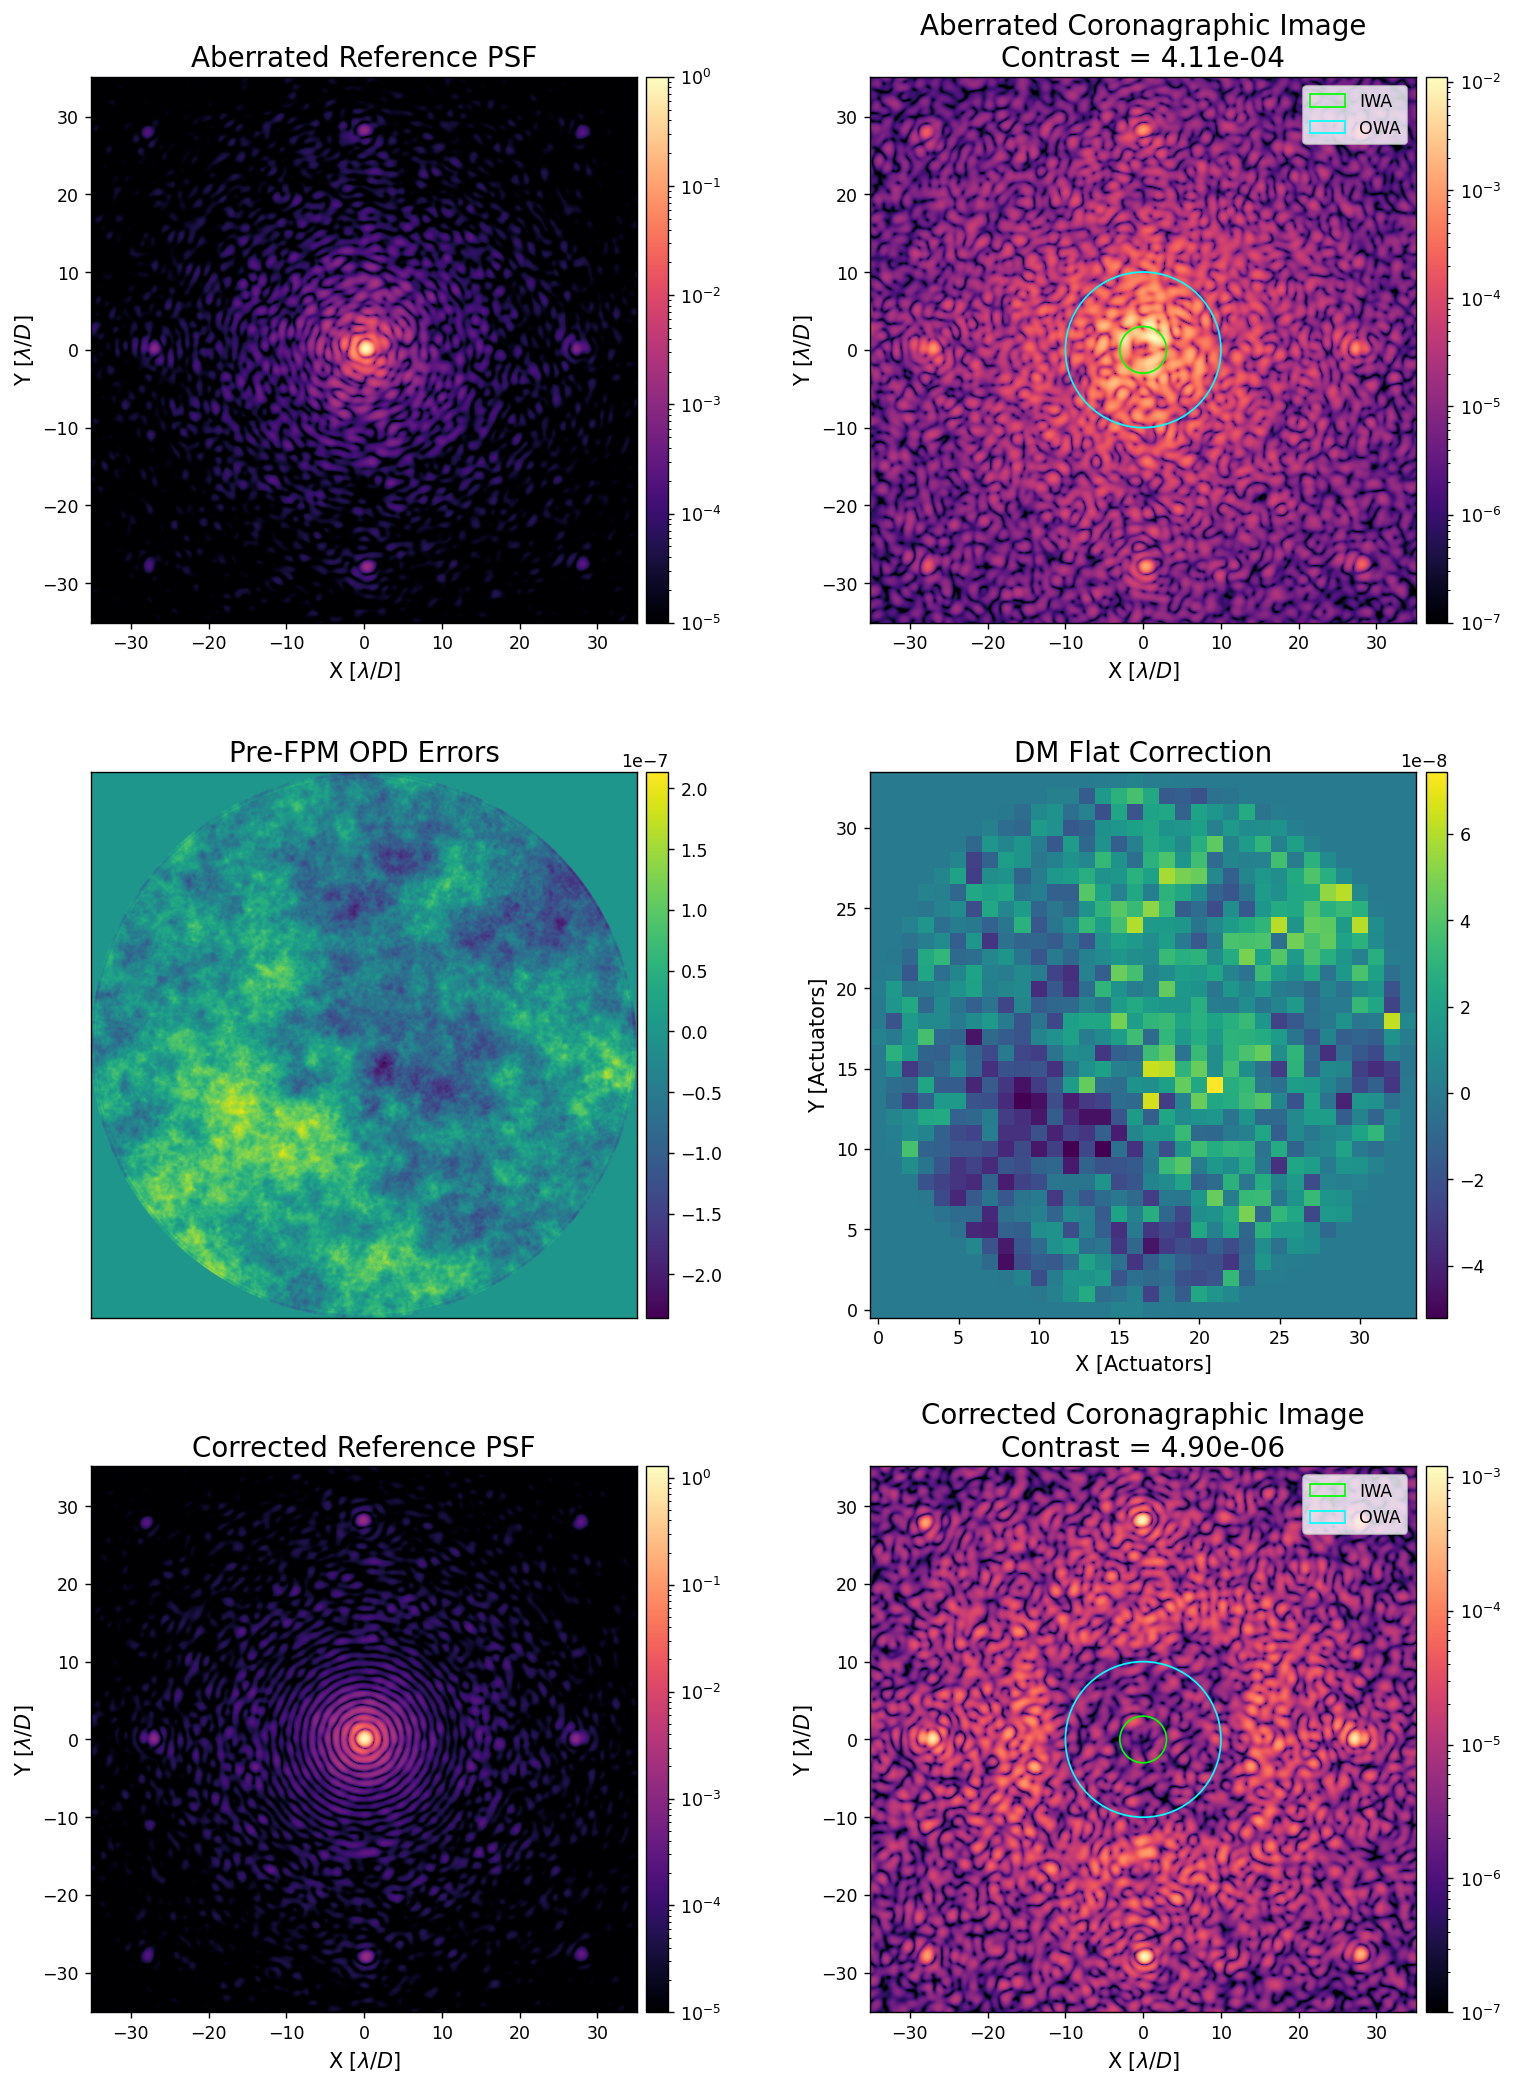

In [121]:
import esc_fresnel.esc_fresnel_subap as esc

reload(esc)
reload(esc_optics)

poppy_log.disabled = True

M = esc.single()
M.npsf = 500
M.wfes = wfes

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    # edge=iwa,
    # rotation=90,
)
utils.imshow([coro_mask])

M.use_vortex = False
ref_psf = M.snap()
Iref = xp.max(ref_psf)
ref_psf /= Iref
M.use_vortex = True
ref_coro_im = M.snap()/Iref

M.set_dm(dm_flat, 0)

M.use_vortex = False
ref_psf_flat = M.snap()
Iref_flat = xp.max(ref_psf_flat)
ref_psf_flat /= Iref
M.use_vortex = True
ref_coro_im_flat = M.snap()/Iref_flat

contrast0 = xp.mean(ref_coro_im[coro_mask])
contrast_flat = xp.mean(ref_coro_im_flat[coro_mask])

ticks = np.arange(-30, 30.01, 10)
psf_center = (M.camsci_pxscl_lamDc/2, M.camsci_pxscl_lamDc/2)
fig, axs = utils.imshow(
    [ref_psf, ref_coro_im,
     prefpm_opd, dm_flat, 
     ref_psf_flat, ref_coro_im_flat], 
    titles=['Aberrated Reference PSF', f'Aberrated Coronagraphic Image\nContrast = {contrast0:.2e}',
            'Pre-FPM OPD Errors', 'DM Flat Correction',
            'Corrected Reference PSF', f'Corrected Coronagraphic Image\nContrast = {contrast_flat:.2e}'],
    title_fzs=[16]*6,
    cmaps=['magma', 'magma', 'viridis', 'viridis', 'magma', 'magma'],
    norms=[LogNorm(1e-5), LogNorm(1e-7), None, None, LogNorm(1e-5), LogNorm(1e-7)],
    pxscls=[M.camsci_pxscl_lamDc, M.camsci_pxscl_lamDc, None, None, M.camsci_pxscl_lamDc, M.camsci_pxscl_lamDc],
    xticks=[ticks, ticks, [], None, ticks, ticks],
    yticks=[ticks, ticks, [], None, ticks, ticks],
    xlabels=['X [$\lambda/D$]', 'X [$\lambda/D$]', None, 'X [Actuators]', 'X [$\lambda/D$]', 'X [$\lambda/D$]'],
    ylabels=['Y [$\lambda/D$]', 'Y [$\lambda/D$]', None, 'Y [Actuators]', 'Y [$\lambda/D$]', 'Y [$\lambda/D$]'],
    label_fzs=[12]*6,
    all_patches=[
        None, 
        [Circle((0,0), 3, fill=False, color='lime', label='IWA'),  Circle((0,0), 10, fill=False, color='cyan', label='OWA'),],
        None, 
        None, 
        None, 
        [Circle((0,0), 3, fill=False, color='lime', label='IWA'),  Circle((0,0), 10, fill=False, color='cyan', label='OWA'),]
    ],
    Nrows=3, Ncols=2,
    figsize=(14,21),
    hspace=0.1, 
    wspace=0.35,
    return_fig=1,
)

axs[0,1].legend()
axs[2,1].legend()
display(fig)

In [81]:
M.Imax_ref

1

# Test M4 and FSM operation.

1


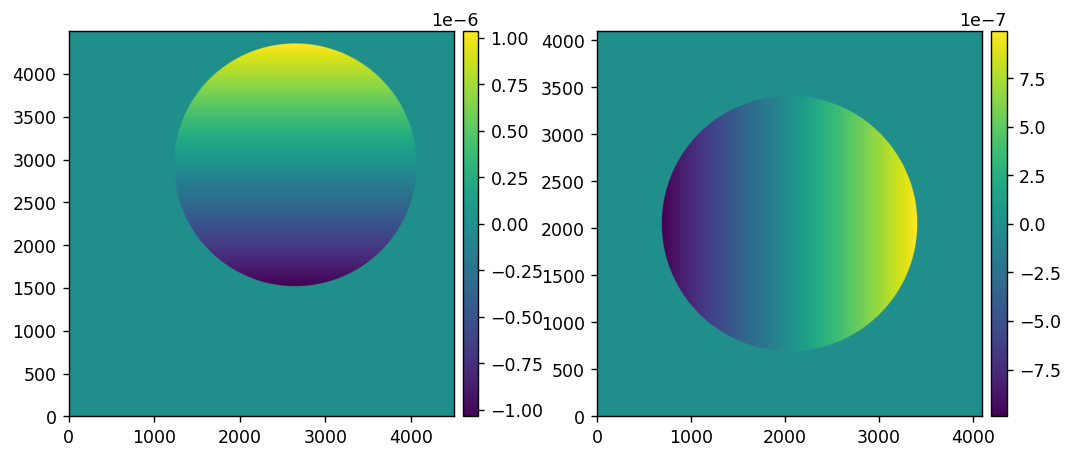

In [3]:
M.set_m4(np.array([0,1]))
M.set_fsm(np.array([1,0]))
imshow(
    [M.M4.opd, M.FSM.opd],
)

In [ ]:
1/1.00045, 

0.9995502024089159

In [ ]:
M.m4_pupil_ratio/(M.npix_m4/M.npix)

np.float64(3.0003810483931463)

1


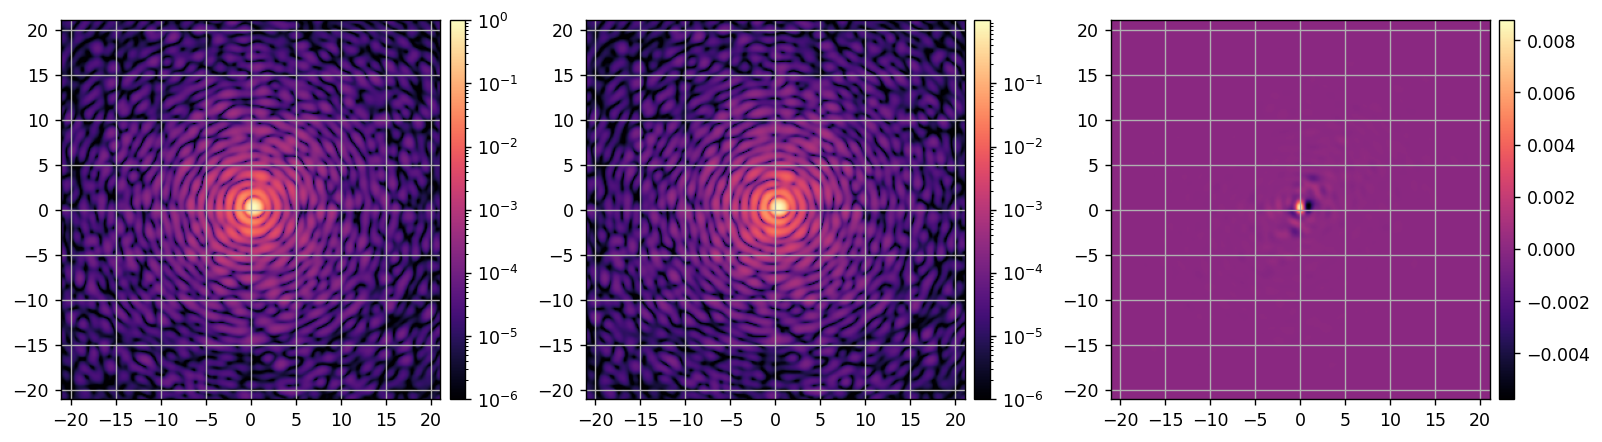

In [11]:
offset = np.array([ 10, 10 ])

m4_fsm_ratio = 1/4

M.npsf = 300
M.use_vortex = False
M.source_offset = (0, 0)
M.set_m4( [0,0] )
M.set_fsm( [0,0] )
psf1 = M.snap()

M.source_offset = offset
M.set_m4( -offset * m4_fsm_ratio)
M.set_fsm( -offset * (1 - m4_fsm_ratio))
psf2 = M.snap()

ticks = np.arange(-20, 20.01, 5)

diff = psf1 - psf2

imshow(
    [psf1, psf2, diff],
    norms=[LogNorm(1e-6), LogNorm(1e-6)],
    grids=[1]*3,
    pxscls=[M.camsci_pxscl_lamDc]*3,
    xticks=[ticks]*3,
    yticks=[ticks]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)


# Use ESC fresnel model to compute the wavefront at each plane and visualize the various pupil and focal planes.

Note that this is very memory intesive and is only meant to be used for understanding and debugging the Fresnel model. Standard propagations should only use calc_wf() or snap() methods, not calc_wfs(). 

In [23]:
M.Nm4

2835

1


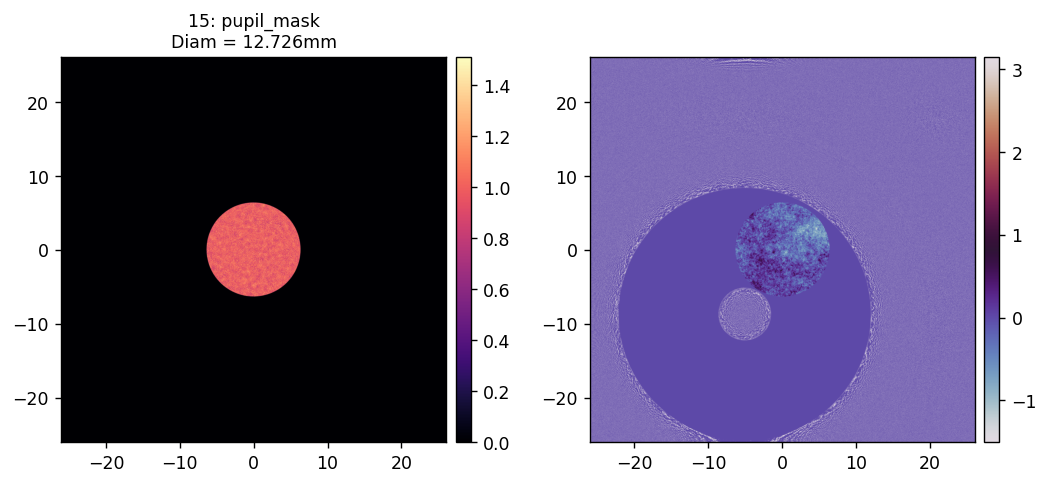

In [25]:
reload(esc)
reload(esc_optics)

poppy_log.disabled = True

M = esc.single(
    # npix=1000, 
    # oversample=6, 
    # oversample=8.192,
)
M.wfes = wfes
# M.use_vortex = True
M.plot_vortex = True # this will display the intermediate steps while propagating through the vortex

# M.m4_corr = 5.5*u.mm
# M.pupil_mask_corr = 8.25*u.mm
# M.fsm_corr = -29.4*u.mm
# M.dm_corr = -6 *u.mm

# M.fsm_corr = -33.9*u.mm
# M.dm_corr = -10.5 *u.mm
# M.lyot_corr = -1.335*u.mm

wfs = M.calc_wfs()

i = 0
i = 15
# i = 5 # M4
# i = 9 # Pupil Mask
# i = 13 # FSM
# i = 18 # DM
# i = 25 # Lyot Plane
# i = 26 # Lyot Stop
wf = wfs[i]
imshow(
    [wf.amplitude, wf.phase], 
    titles=[f'{i:d}: '+wf.location[6:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm'], 
    pxscls=[wf.pixelscale.to_value(u.mm/u.pix)]*2,
    # npix=[1.5*M.npix]*2, 
    cmaps=['magma', 'twilight'],
    # norms=[None, Normalize(-0.1, 0.1)],
)

In [11]:
31.742 * 6.5/2.43

84.90658436213991

In [7]:
6.5/2.43

2.674897119341564

In [ ]:
# mag = 
12.726

82719.00000000001

1


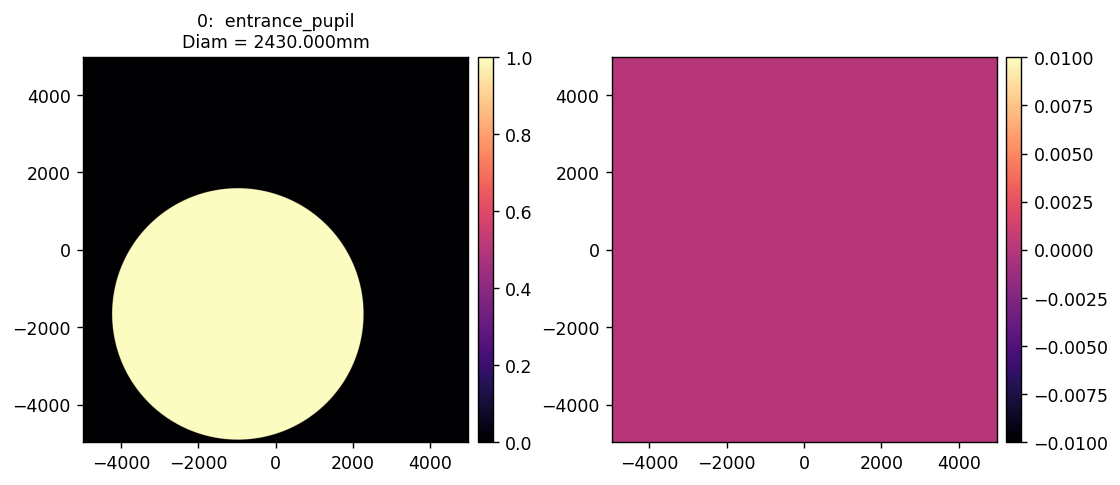

1


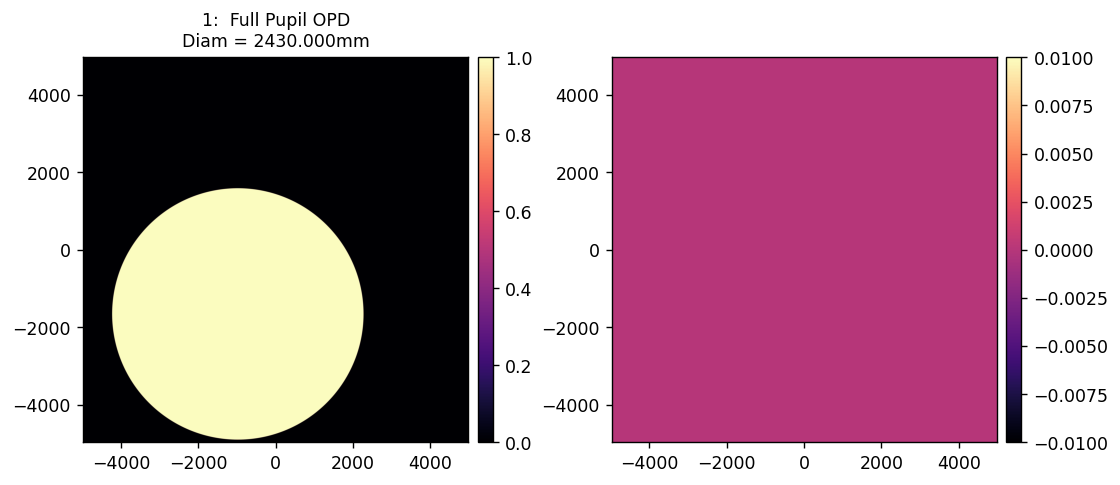

1


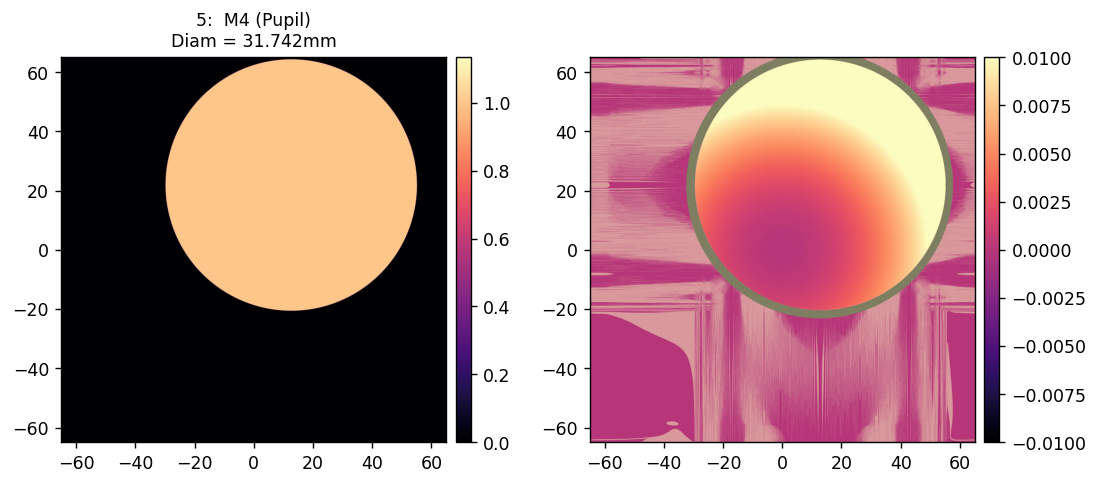

Focal Plane Correction:  0.0 mm
1


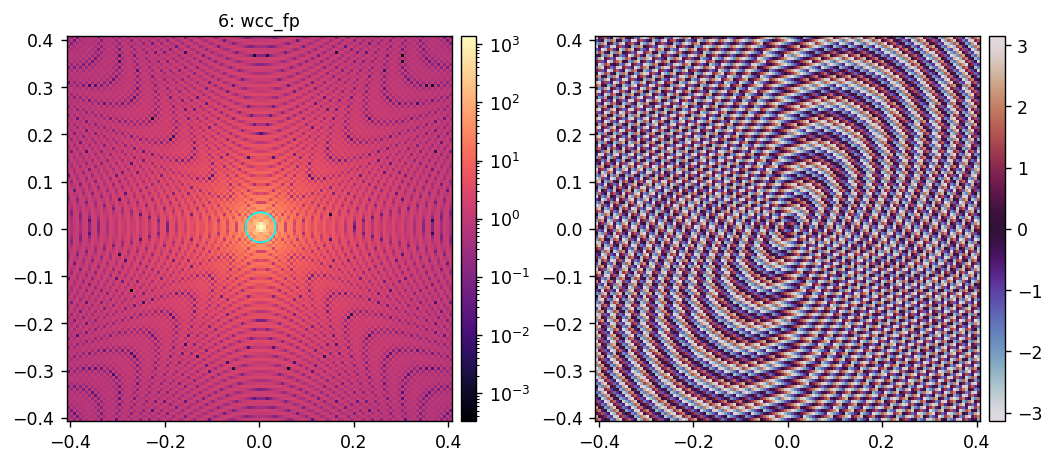

1


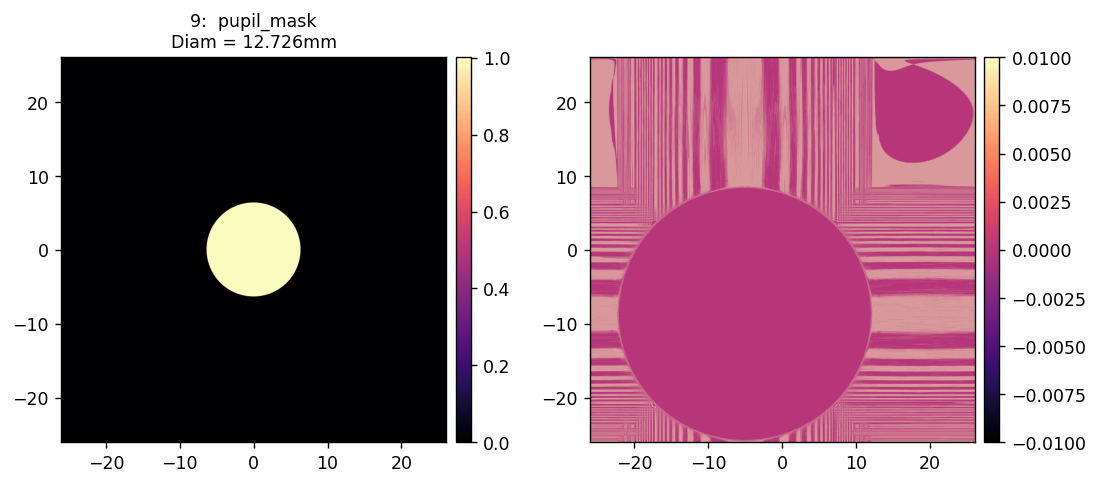

Focal Plane Correction:  0.0 mm
1


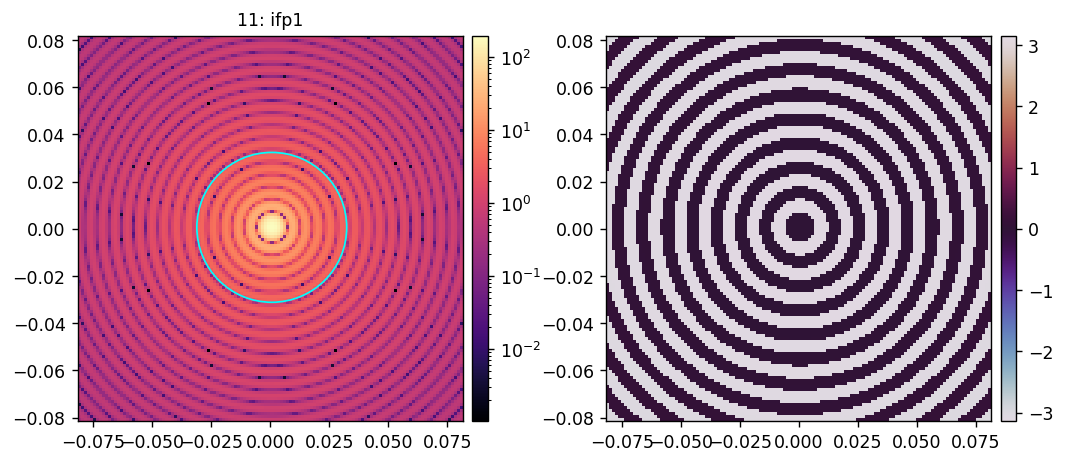

1


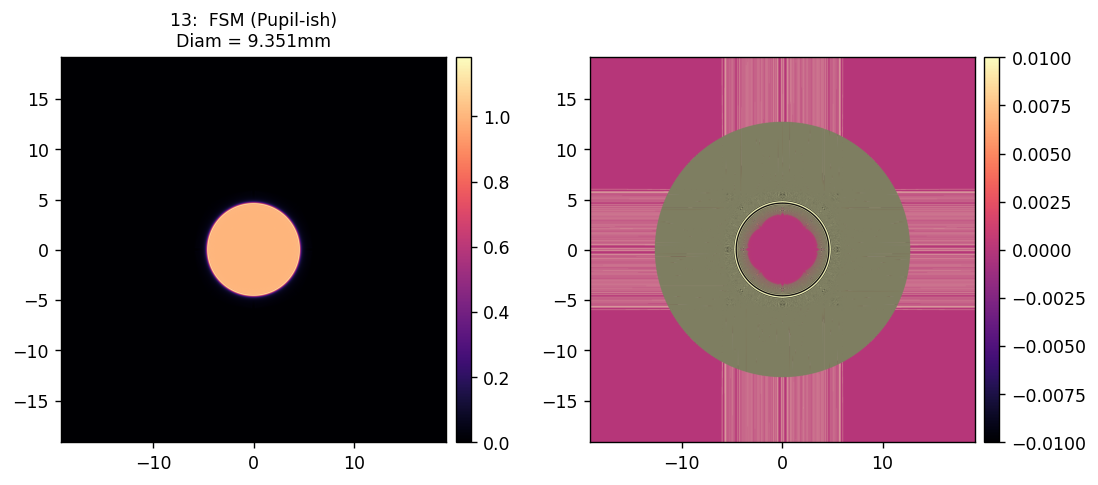

Focal Plane Correction:  0.0 mm
1


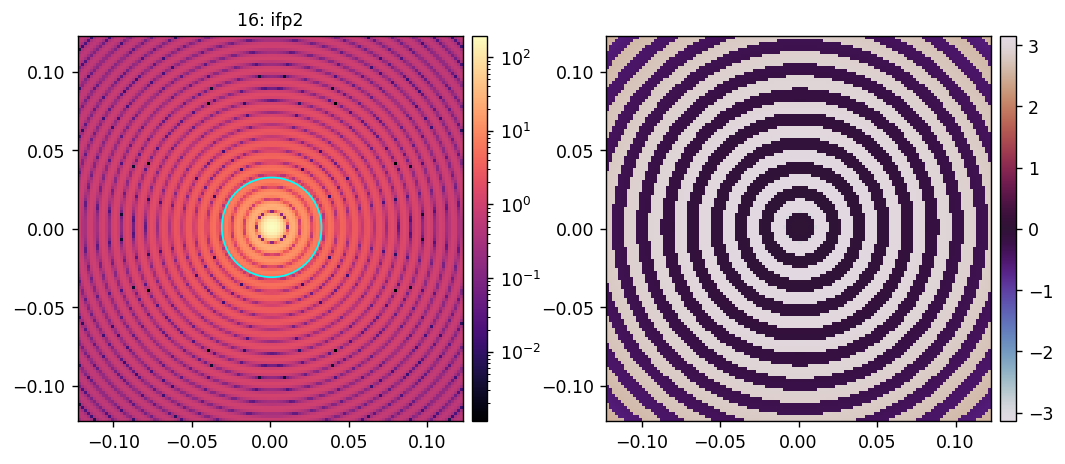

1


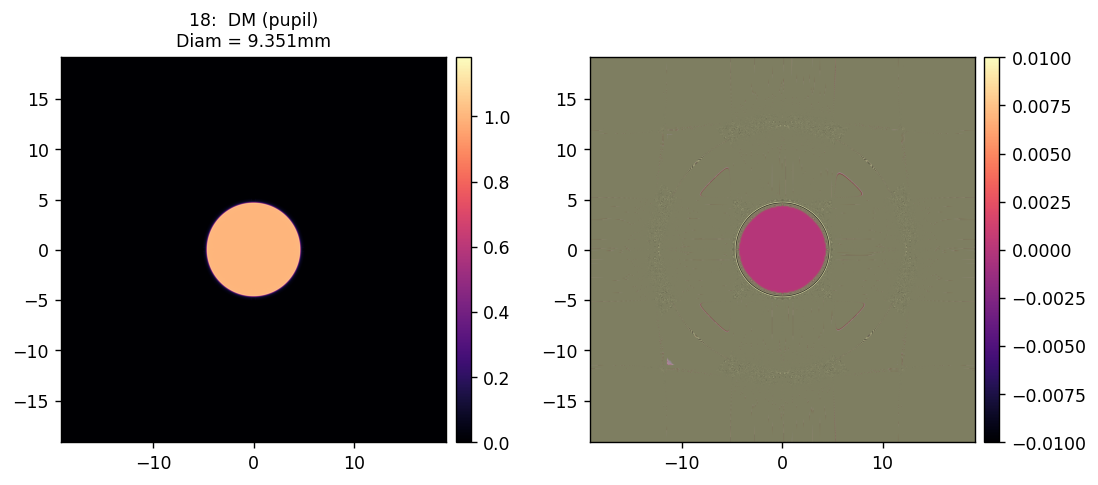

Focal Plane Correction:  -1541.0562467009754 mm
1


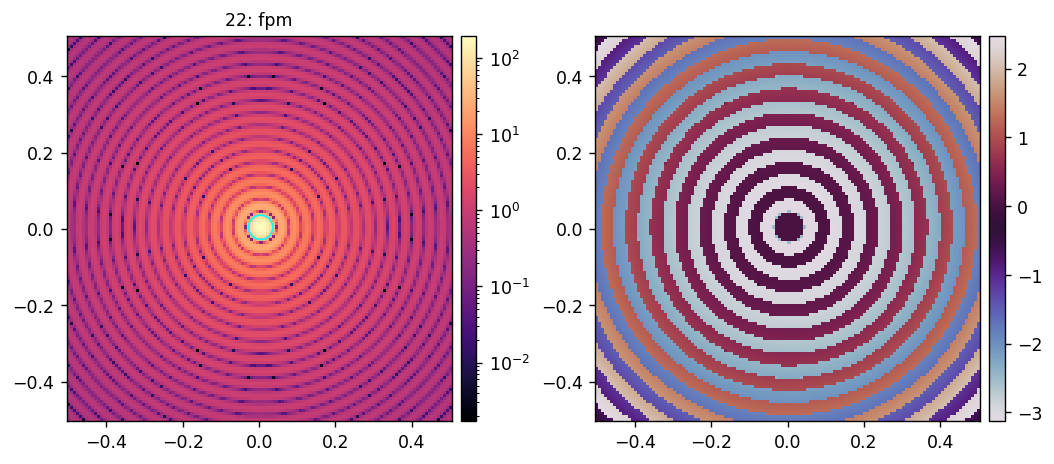

Focal Plane Correction:  0.0 mm
1


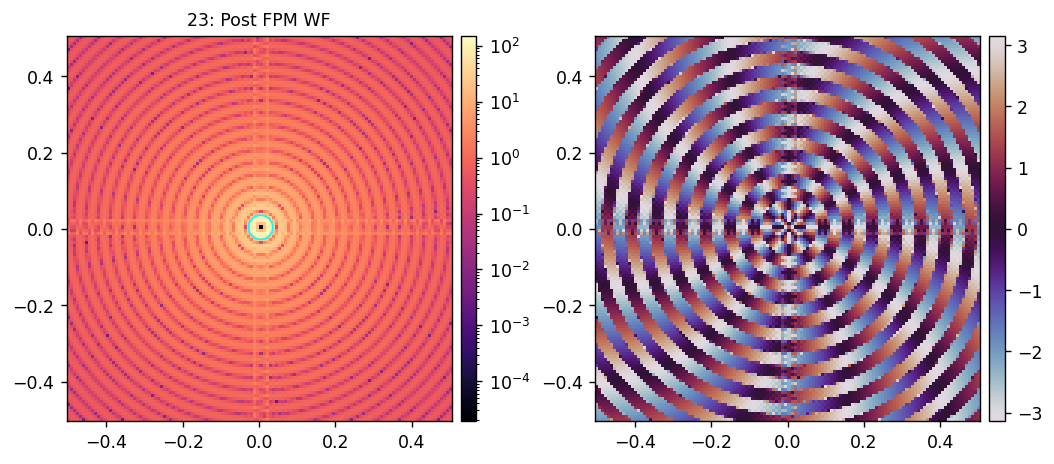

1


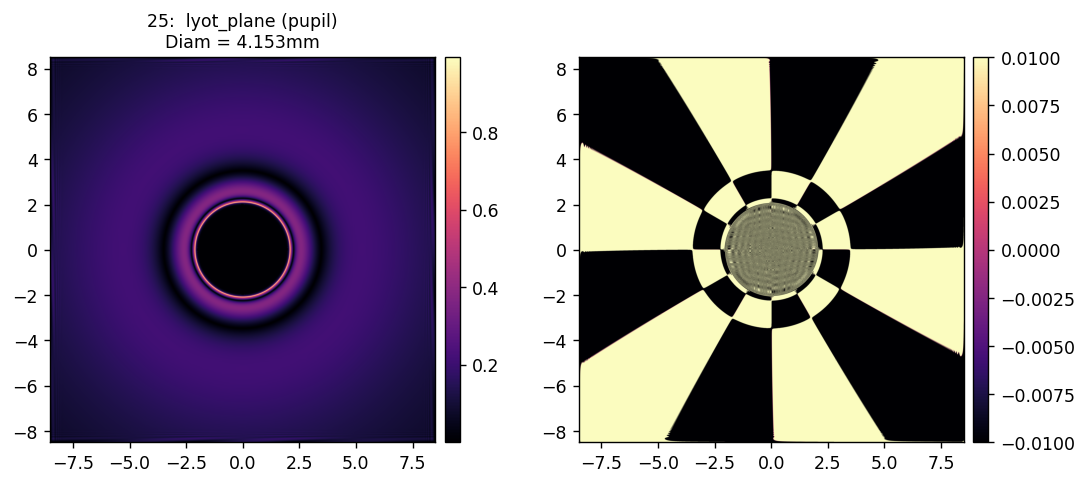

1


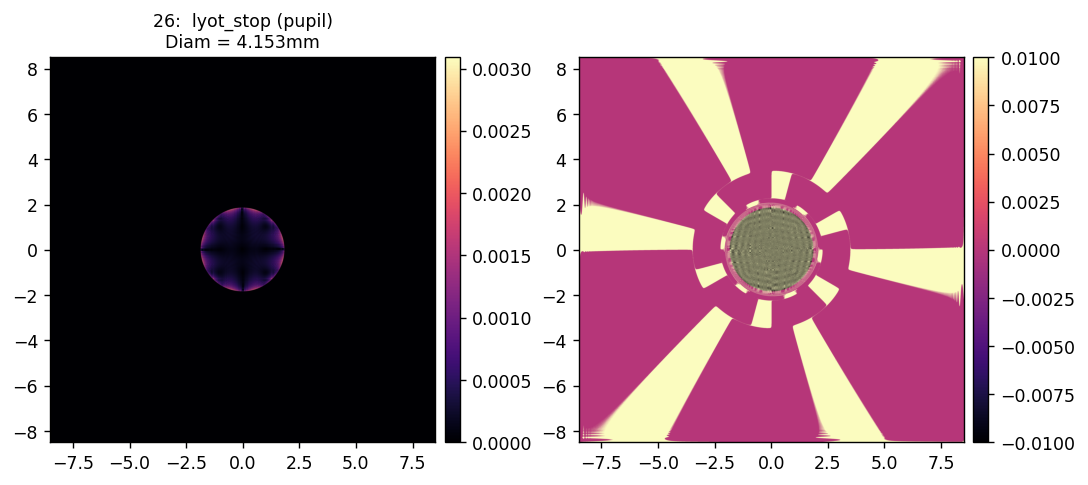

Focal Plane Correction:  0.0 mm
1


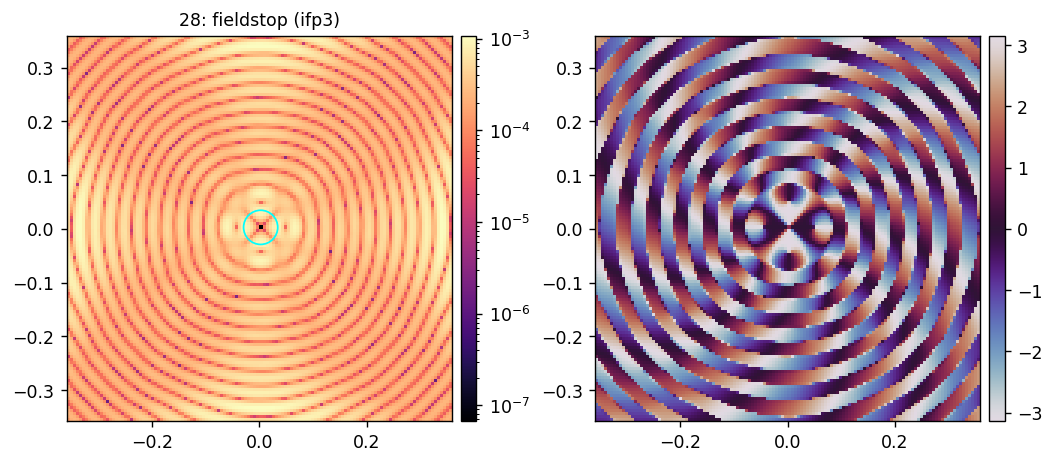

Focal Plane Correction:  0.0 mm
1


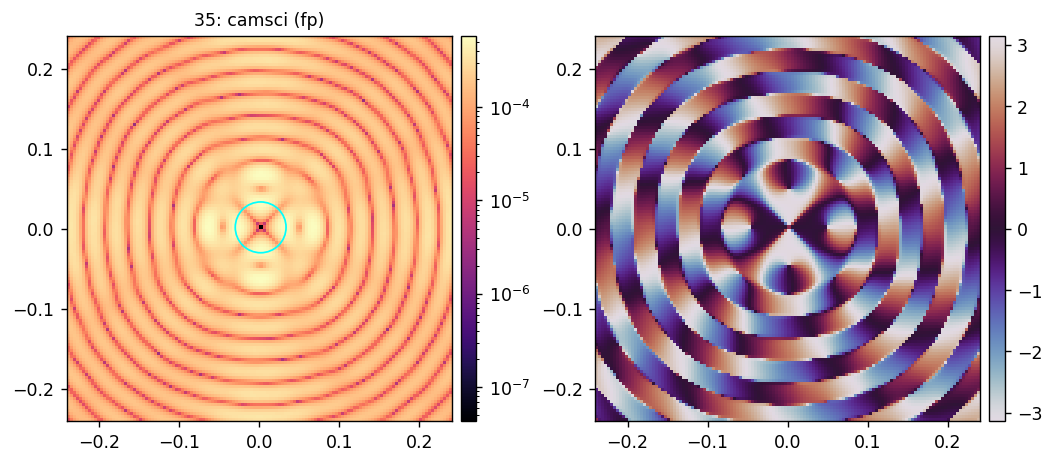

In [29]:
for i,wf in enumerate(wfs):
    if 'fp' in wf.location.lower():
        f_corr = wf.z_w0 - wf.z
        print('Focal Plane Correction: ', f_corr.to(u.mm))
        pxscl_mm = wf.pixelscale.to_value(u.mm/u.pix)
        airy_rad = 31.752*u.um
        imshow(
            [wf.amplitude, wf.phase,],
            titles=[f'{i:d}: '+wf.location[6:]], 
            cmaps=['magma', 'twilight'],
            pxscls=[pxscl_mm]*2, 
            npix=[128]*2, 
            norms=[LogNorm(), None],
            all_patches=[[Circle((pxscl_mm/2, pxscl_mm/2), airy_rad.to_value(u.mm), color='cyan', fill=False)]]
        )
    elif 'pupil' in wf.location.lower():
        imshow(
            [wf.amplitude, wf.phase], 
            titles=[f'{i:d}: '+wf.location[5:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm'], 
            pxscls=[wf.pixelscale.to_value(u.mm/u.pix)]*2, 
            # npix=[2.5*M.npix], 
            cmaps=['magma', 'magma'],
            norms=[None, Normalize(vmin=-0.01, vmax=0.01)],
        )

# Use the esc_fresnel.multi() class in order to do parallelized propagations to simulate a broadband image. This requires the Ray package to perform the parallelization. 

In [2]:
reload(esc)

import ray
ray_esc = ray.remote(esc.single)

N_waves = 5
bw = 0.05
wavelength_c = 650*u.nm
waves = np.linspace(wavelength_c*(1 - bw/2), wavelength_c*(1 + bw/2), N_waves)
print(waves)

[633.75  641.875 650.    658.125 666.25 ] nm


In [3]:
ACTORS = []
for i in range(N_waves):
    params = {
        'wavelength':waves[i],
        # 'npix':1000,
        # 'oversample':4.096,
    }
    ACTORS.append(ray_esc.options(num_cpus=4, num_gpus=1).remote(**params))


2025-03-19 09:35:32,290	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


(pid=1364552) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
(pid=1364552)   cupy._util.experimental('cupyx.jit.rawkernel')
(single pid=1364552) Oversampling > 2x suggested for reliable results in Fresnel propagation.
(pid=1364548) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future. [repeated 4x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=1364548)   cupy._util.experimental('cupyx.jit.rawkernel') [repeated 4x across cluster]
(single pid=1364542) Oversampling > 2x suggested for reliable results in Fresnel propagation.


1


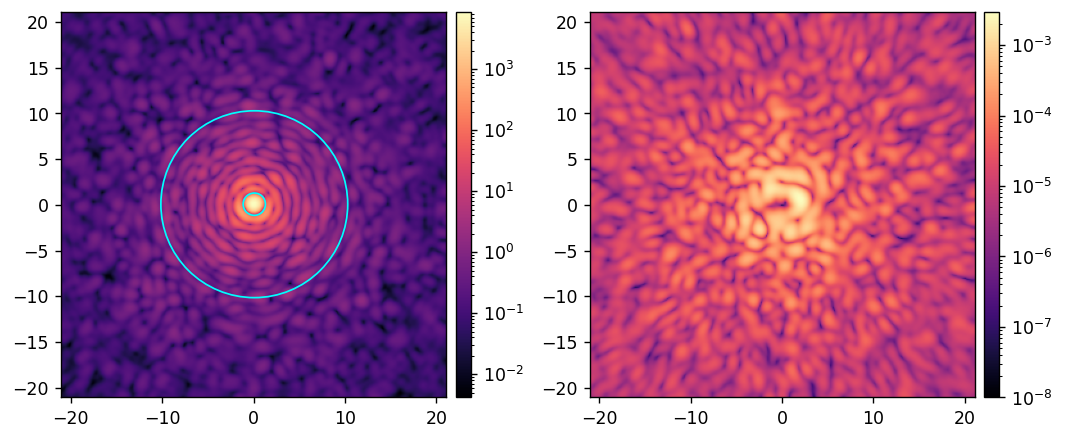

In [12]:
reload(esc)
M = esc.parallel(ACTORS)
M.setattr('wfes', wfes)

M.setattr('Imax_ref', 1)
M.setattr('use_vortex', False)
ref_psf = M.snap()
# M.Imax_ref = xp.max(ref_psf)
M.setattr('Imax_ref', xp.max(ref_psf))

M.setattr('use_vortex', True)
ref_coro_im = M.snap()

psf_center = (M.camsci_pxscl_lamDc/2, M.camsci_pxscl_lamDc/2)
imshow(
    [ref_psf/M.Imax_ref, ref_coro_im], 
    cmaps=['magma']*2,
    norms=[LogNorm(), LogNorm(1e-8)],
    pxscls=[M.camsci_pxscl_lamDc]*2,
    all_patches=[ [Circle(psf_center, 1.22, fill=False, color='cyan'), Circle(psf_center, 10.22, fill=False, color='cyan')] ],
)

In [9]:
M.npix, M.oversample

(1000, 4.096)

In [11]:
M.setattr('use_vortex', True)

%timeit -n 10 M.snap()

394 ms ± 3.74 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


1


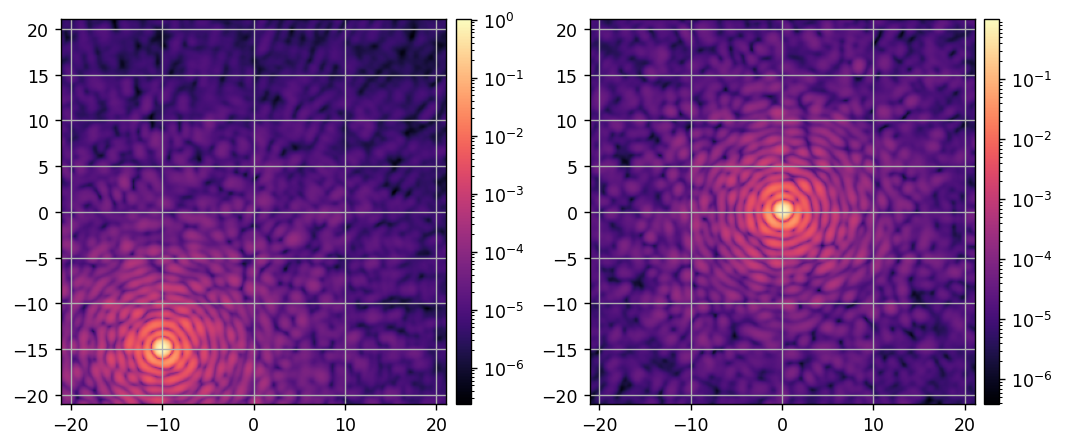

In [19]:
source_offset = np.array([-10, -15])
M.setattr('use_vortex', False)

M.setattr('source_offset', source_offset)
M.set_m4( [0, 0] )
M.set_fsm( [0, 0] )
psf1 = M.snap()

M.setattr('source_offset', source_offset)
M.set_m4( -source_offset )
# M.set_fsm( -source_offset )
psf2 = M.snap()

imshow(
    [psf1, psf2], 
    cmaps=['magma']*2,
    norms=[LogNorm(), LogNorm()],
    pxscls=[M.camsci_pxscl_lamDc]*2,
    grids=[1, 1],
)